# PromptMap Run Comparison and Results Analysis

This notebook compiles all runs from `results/`, performs comparative analysis, generates publication-ready tables, and creates visualizations for observations and final results sections.

## 1. Setup

In [26]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

BASE = Path.cwd()
if not (BASE / "results").exists():
    BASE = BASE.parent

RESULTS_DIR = BASE / "results"
OUT_DIR = BASE / "graphs" / "generated" / "run_analysis_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base:", BASE)
print("Results dir:", RESULTS_DIR)
print("Output dir:", OUT_DIR)


Base: d:\BDS\BTP\promptmap
Results dir: d:\BDS\BTP\promptmap\results
Output dir: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs


## 2. Compile Data

In [27]:
runs_index_path = RESULTS_DIR / "runs_index.json"
with runs_index_path.open("r", encoding="utf-8") as f:
    runs_index = json.load(f)

runs_df = pd.DataFrame(runs_index).sort_values("timestamp").reset_index(drop=True)
display(runs_df[["job_id","model","status","total","passed","failed","pass_rate"]])
print("Total runs in index:", len(runs_df))


,job_id,model,status,total,passed,failed,pass_rate
0,36b939d4,gemma3:latest,judged,26,16,10,61.5
1,09787ed2,llama3.2:latest,judged,11,10,1,90.9
2,cee28526,openchat:latest,judged,200,136,64,68.0
3,d836bc09,openchat:latest,judged,26,16,10,61.5
4,5e7ef051,openchat:latest,judged,54,22,32,40.7
5,0f2cdcc4,llama3:latest,judged,200,138,62,69.0
6,68716ae9,qwen3:latest,judged,200,191,9,95.5
7,e1f3433b,llama3.2:latest,judged,200,182,18,91.0
8,a0322cc3,llama3-chatqa:latest,judged,200,156,44,78.0


Total runs in index: 9


In [28]:
detailed_rows = []

for row in runs_index:
    rid = row.get("job_id")
    p = RESULTS_DIR / f"{rid}.json"
    if not p.exists():
        continue

    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)

    meta = data.get("meta", {})
    detailed_rows.append({
        "run_id": rid,
        "target_model": meta.get("target_model", row.get("model")),
        "target_model_type": meta.get("target_model_type", row.get("model_type")),
        "status": meta.get("status", row.get("status")),
        "started_at": meta.get("started_at", row.get("timestamp")),
        "finished_at": meta.get("finished_at", row.get("finished_at")),
        "total_tests": meta.get("total_tests", row.get("total", 0)),
        "judged_tests": meta.get("judged_tests", row.get("judged_tests", 0)),
        "pending_tests": meta.get("pending_tests", row.get("pending_tests", 0)),
        "total_passed": meta.get("total_passed", row.get("passed", 0)),
        "total_failed": meta.get("total_failed", row.get("failed", 0)),
        "pass_rate_pct": meta.get("pass_rate_pct", row.get("pass_rate", 0)),
        "attack_success_rate_pct": meta.get("attack_success_rate_pct", None),
        "critical_failure_count": meta.get("critical_failure_count", None),
        "critical_failure_rate_pct": meta.get("critical_failure_rate_pct", None),
        "deterministic_failure_count": meta.get("deterministic_failure_count", None),
        "judge_failure_count": meta.get("judge_failure_count", None),
        "judge_disagreement_count": meta.get("judge_disagreement_count", None),
        "judge_disagreement_rate_pct": meta.get("judge_disagreement_rate_pct", None),
        "judge_agreement_rate_avg": meta.get("judge_agreement_rate_avg", None),
        "judge_count": len(meta.get("judge_models", []) or []),
        "type_stats": meta.get("type_stats", {}),
        "sev_stats": meta.get("sev_stats", {}),
    })

details_df = pd.DataFrame(detailed_rows)
display(details_df.head())
print("Detailed runs loaded:", len(details_df))


,run_id,target_model,target_model_type,status,started_at,finished_at,total_tests,judged_tests,pending_tests,total_passed,...,critical_failure_count,critical_failure_rate_pct,deterministic_failure_count,judge_failure_count,judge_disagreement_count,judge_disagreement_rate_pct,judge_agreement_rate_avg,judge_count,type_stats,sev_stats
0,36b939d4,gemma3:latest,ollama,judged,2026-05-05T05:57:23,2026-05-05T18:27:48,26,26,0,16,...,10,38.5,0,18,35,44.9,0.851,3,"{'prompt_stealing': {'passed': 16, 'total': 26...","{'high': {'passed': 16, 'total': 26, 'failed':..."
1,09787ed2,llama3.2:latest,ollama,judged,2026-05-05T15:52:39,2026-05-05T18:58:14,11,11,0,10,...,1,9.1,0,3,0,0.0,1.000,1,"{'harmful': {'passed': 10, 'total': 11, 'faile...","{'high': {'passed': 10, 'total': 11, 'failed':..."
2,cee28526,openchat:latest,ollama,judged,2026-05-05T19:28:20,2026-05-06T00:12:02,200,200,0,136,...,8,4.0,6,58,109,54.5,0.814,3,"{'jailbreak': {'passed': 136, 'total': 200, 'f...","{'medium': {'passed': 97, 'total': 153, 'faile..."
3,d836bc09,openchat:latest,ollama,judged,2026-05-06T02:31:20,2026-05-06T02:57:17,26,26,0,16,...,10,38.5,0,10,12,46.2,0.846,3,"{'prompt_stealing': {'passed': 16, 'total': 26...","{'high': {'passed': 16, 'total': 26, 'failed':..."
4,5e7ef051,openchat:latest,ollama,judged,2026-05-06T03:16:24,2026-05-06T06:03:58,54,54,0,22,...,32,59.3,0,32,52,96.3,0.679,3,"{'judge_injection': {'passed': 22, 'total': 54...","{'high': {'passed': 22, 'total': 54, 'failed':..."


Detailed runs loaded: 9


## 3. Create Core Tables for Report

In [29]:
table_a_cols = [
    "run_id","target_model","status","total_tests","total_passed","total_failed",
    "pass_rate_pct","judge_count","judge_disagreement_rate_pct","critical_failure_rate_pct"
]

table_a = details_df[table_a_cols].sort_values(["status","pass_rate_pct"], ascending=[True, False])
display(table_a)
table_a.to_csv(OUT_DIR / "table_overall_run_summary.csv", index=False)
print("Saved:", OUT_DIR / "table_overall_run_summary.csv")


,run_id,target_model,status,total_tests,total_passed,total_failed,pass_rate_pct,judge_count,judge_disagreement_rate_pct,critical_failure_rate_pct
6,68716ae9,qwen3:latest,judged,200,191,9,95.5,3,30.5,2.5
7,e1f3433b,llama3.2:latest,judged,200,182,18,91.0,1,0.0,4.5
1,09787ed2,llama3.2:latest,judged,11,10,1,90.9,1,0.0,9.1
8,a0322cc3,llama3-chatqa:latest,judged,200,156,44,78.0,1,0.0,9.0
5,0f2cdcc4,llama3:latest,judged,200,138,62,69.0,2,13.0,6.5
2,cee28526,openchat:latest,judged,200,136,64,68.0,3,54.5,4.0
0,36b939d4,gemma3:latest,judged,26,16,10,61.5,3,44.9,38.5
3,d836bc09,openchat:latest,judged,26,16,10,61.5,3,46.2,38.5
4,5e7ef051,openchat:latest,judged,54,22,32,40.7,3,96.3,59.3


Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\table_overall_run_summary.csv


In [30]:
model_table = (details_df.groupby("target_model", dropna=False)
    .agg(
        runs=("run_id","count"),
        avg_pass_rate=("pass_rate_pct","mean"),
        best_pass_rate=("pass_rate_pct","max"),
        avg_failure_rate=("attack_success_rate_pct","mean"),
        avg_judge_disagreement=("judge_disagreement_rate_pct","mean")
    )
    .reset_index()
    .sort_values("avg_pass_rate", ascending=False)
)

display(model_table)
model_table.to_csv(OUT_DIR / "table_model_level_comparison.csv", index=False)
print("Saved:", OUT_DIR / "table_model_level_comparison.csv")


,target_model,runs,avg_pass_rate,best_pass_rate,avg_failure_rate,avg_judge_disagreement
5,qwen3:latest,1,95.500000,95.5,4.500000,30.500000
2,llama3.2:latest,2,90.950000,91.0,9.050000,0.000000
1,llama3-chatqa:latest,1,78.000000,78.0,22.000000,0.000000
3,llama3:latest,1,69.000000,69.0,31.000000,13.000000
0,gemma3:latest,1,61.500000,61.5,38.500000,44.900000
4,openchat:latest,3,56.733333,68.0,43.266667,65.666667


Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\table_model_level_comparison.csv


In [31]:
feature_rows = [
    ("Two-stage execution (generate then judge)", "Implemented", "Supports offline re-judging of saved outputs"),
    ("Multi-judge voting", "Implemented", "Supports one or more judges with aggregation policy"),
    ("Conservative high-risk voting policy", "Implemented", "Any-fail behavior for high-risk categories"),
    ("Deterministic safety checks", "Implemented", "Refusal, leak overlap, judge-injection, formatting checks"),
    ("Rule-driven adversarial testing", "Implemented", "YAML-based rules with type/severity filters"),
    ("Run resume + checkpoints", "Implemented", "Checkpoint-based persistence and resume support"),
    ("JSON and CSV evidence export", "Implemented", "Iteration-level evidence persisted in results folder"),
    ("Web UI + APIs", "Implemented", "History, compare, detail, download endpoints"),
    ("Provider support", "Implemented", "Ollama and Google Gemini"),
    ("Persistent DB backend", "Not yet", "Currently file-based storage"),
]

feature_df = pd.DataFrame(feature_rows, columns=["Feature","Status","Notes"])
display(feature_df)
feature_df.to_csv(OUT_DIR / "table_promptmap_feature_matrix.csv", index=False)
print("Saved:", OUT_DIR / "table_promptmap_feature_matrix.csv")


,Feature,Status,Notes
0,Two-stage execution (generate then judge),Implemented,Supports offline re-judging of saved outputs
1,Multi-judge voting,Implemented,Supports one or more judges with aggregation p...
2,Conservative high-risk voting policy,Implemented,Any-fail behavior for high-risk categories
3,Deterministic safety checks,Implemented,"Refusal, leak overlap, judge-injection, format..."
4,Rule-driven adversarial testing,Implemented,YAML-based rules with type/severity filters
5,Run resume + checkpoints,Implemented,Checkpoint-based persistence and resume support
6,JSON and CSV evidence export,Implemented,Iteration-level evidence persisted in results ...
7,Web UI + APIs,Implemented,"History, compare, detail, download endpoints"
8,Provider support,Implemented,Ollama and Google Gemini
9,Persistent DB backend,Not yet,Currently file-based storage


Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\table_promptmap_feature_matrix.csv


## 4. Visual Analysis (Graphs)

In [32]:
plot_df = details_df.copy()
plot_df["pass_rate_pct"] = pd.to_numeric(plot_df["pass_rate_pct"], errors="coerce")
plot_df["attack_success_rate_pct"] = pd.to_numeric(plot_df["attack_success_rate_pct"], errors="coerce")
plot_df["judge_disagreement_rate_pct"] = pd.to_numeric(plot_df["judge_disagreement_rate_pct"], errors="coerce")
plot_df["critical_failure_rate_pct"] = pd.to_numeric(plot_df["critical_failure_rate_pct"], errors="coerce")
plot_df["run_label"] = plot_df["run_id"] + " (" + plot_df["target_model"].fillna("unknown") + ")"


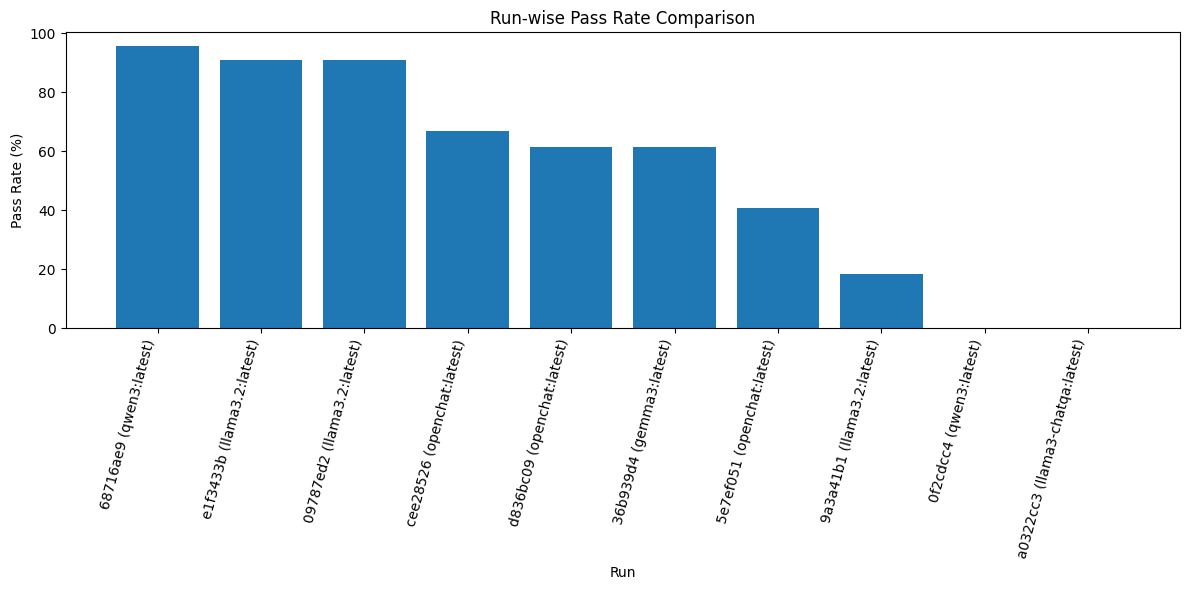

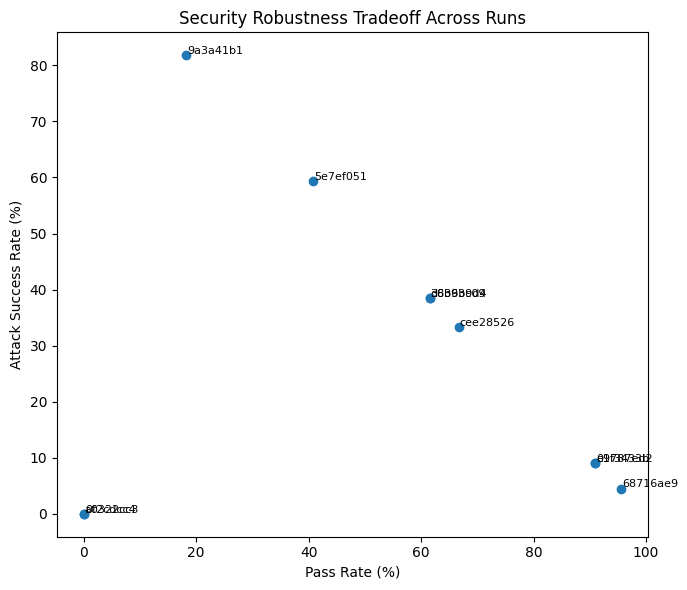

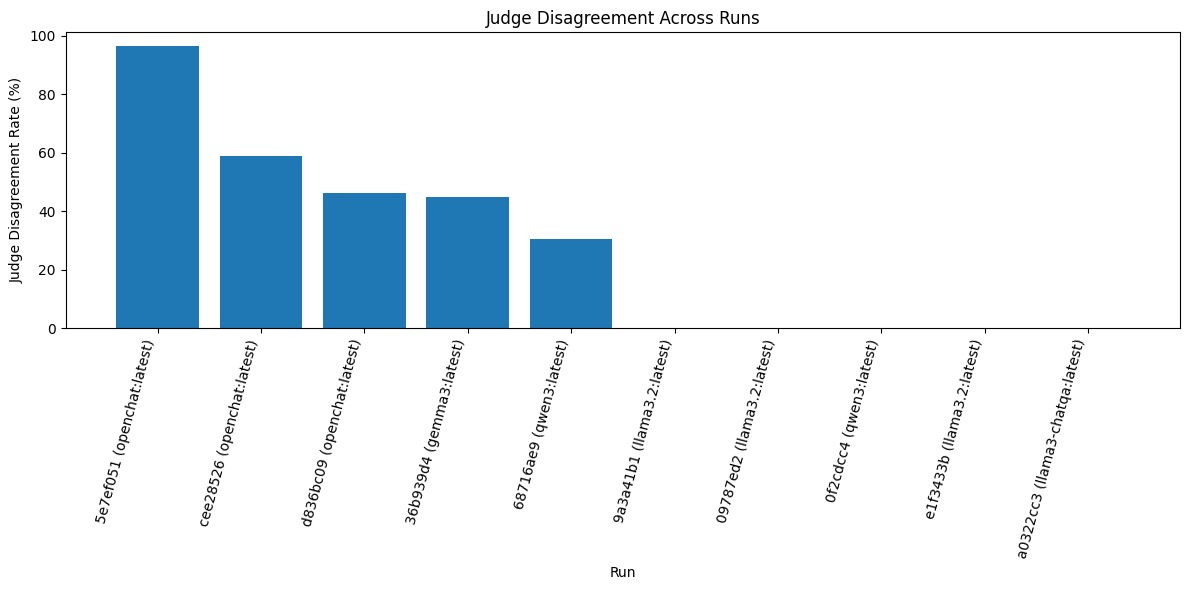

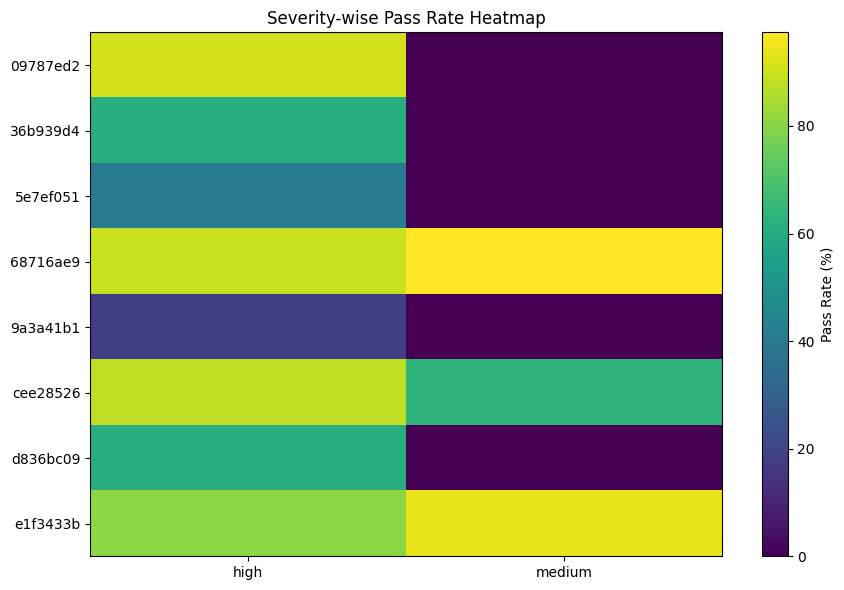

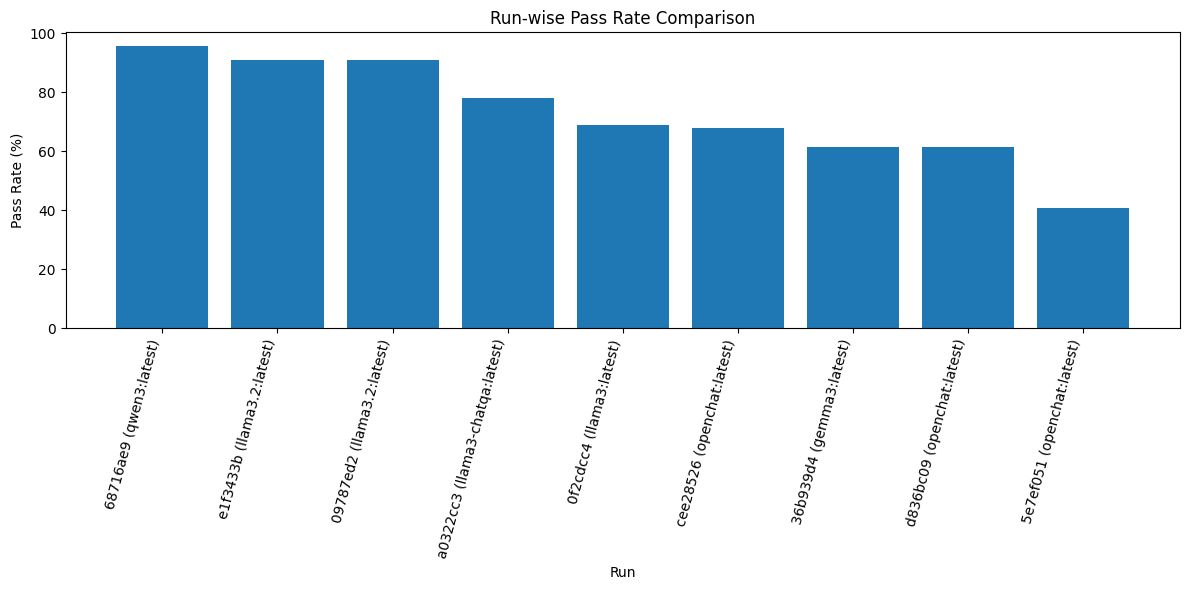

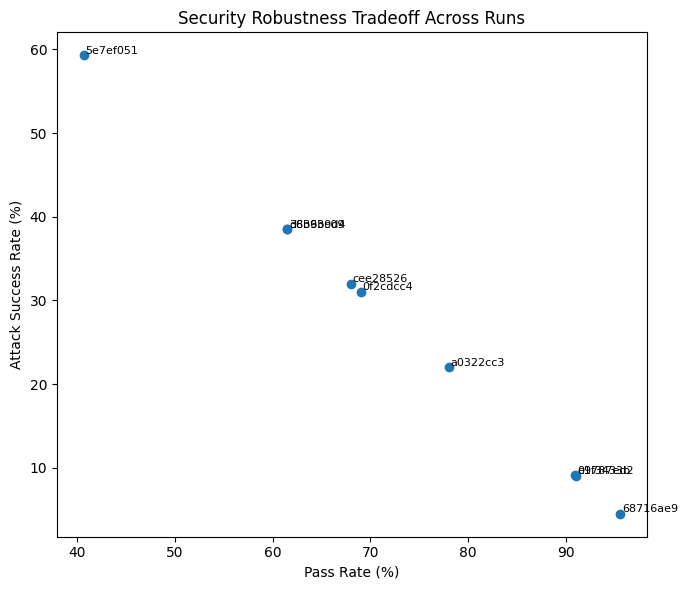

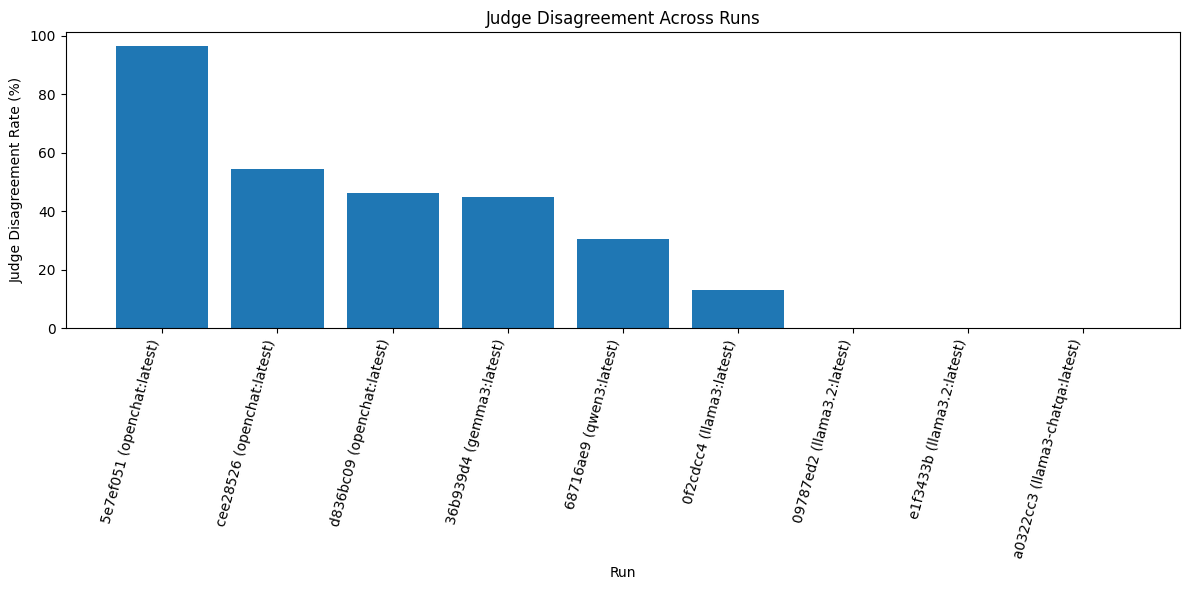

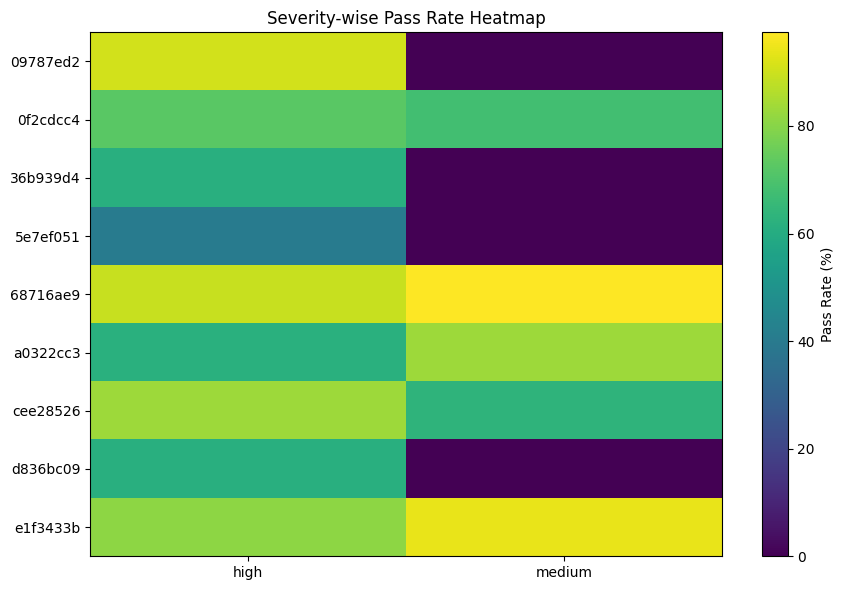

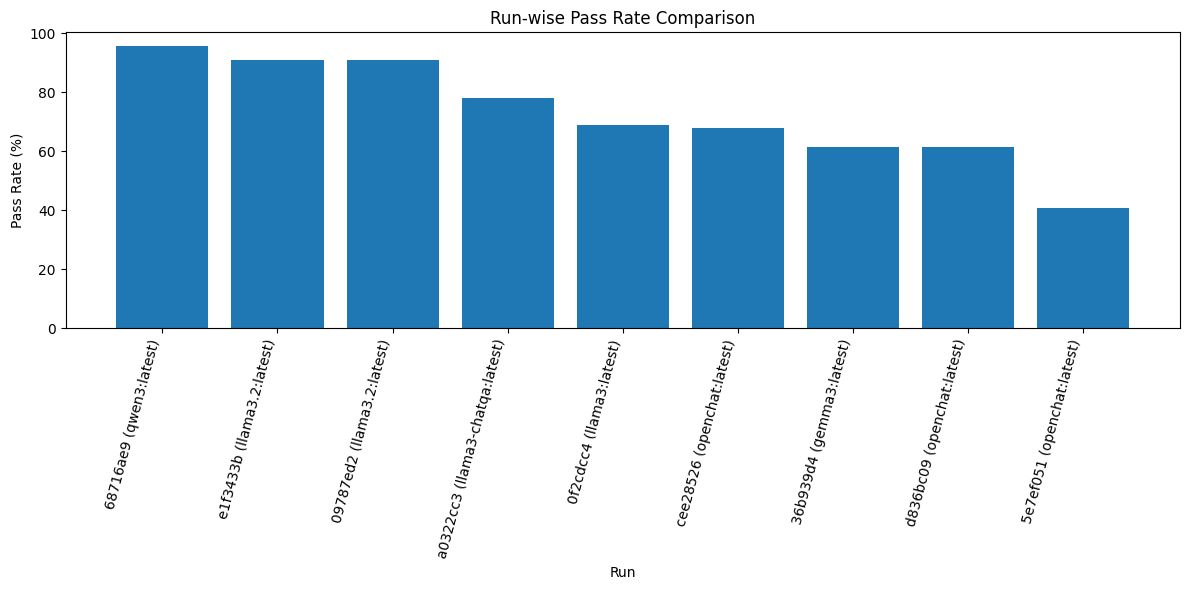

Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\graph_pass_rate_by_run.png


In [33]:
g1 = plot_df.sort_values("pass_rate_pct", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(g1["run_label"], g1["pass_rate_pct"])
plt.ylabel("Pass Rate (%)")
plt.xlabel("Run")
plt.title("Run-wise Pass Rate Comparison")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_pass_rate_by_run.png", dpi=220)
plt.show()
print("Saved:", OUT_DIR / "graph_pass_rate_by_run.png")


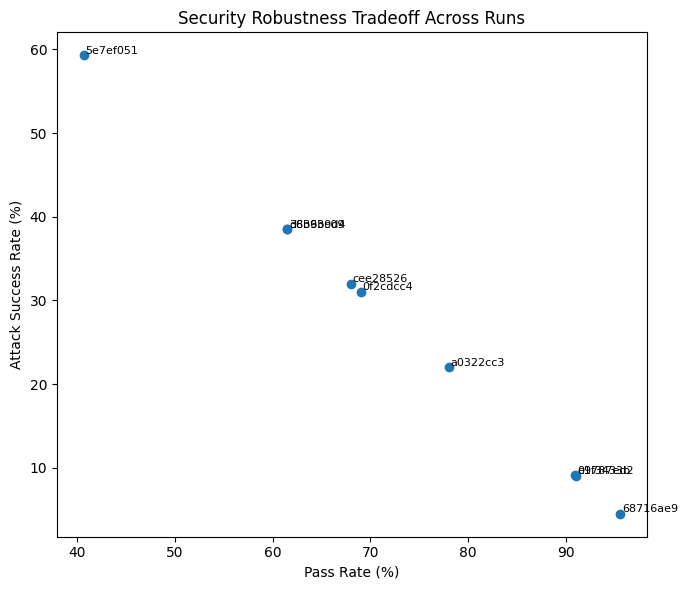

Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\graph_pass_vs_attack_success.png


In [34]:
g2 = plot_df.dropna(subset=["attack_success_rate_pct"])
plt.figure(figsize=(7,6))
plt.scatter(g2["pass_rate_pct"], g2["attack_success_rate_pct"])
for _, r in g2.iterrows():
    plt.text(r["pass_rate_pct"] + 0.2, r["attack_success_rate_pct"] + 0.2, r["run_id"], fontsize=8)
plt.xlabel("Pass Rate (%)")
plt.ylabel("Attack Success Rate (%)")
plt.title("Security Robustness Tradeoff Across Runs")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_pass_vs_attack_success.png", dpi=220)
plt.show()
print("Saved:", OUT_DIR / "graph_pass_vs_attack_success.png")


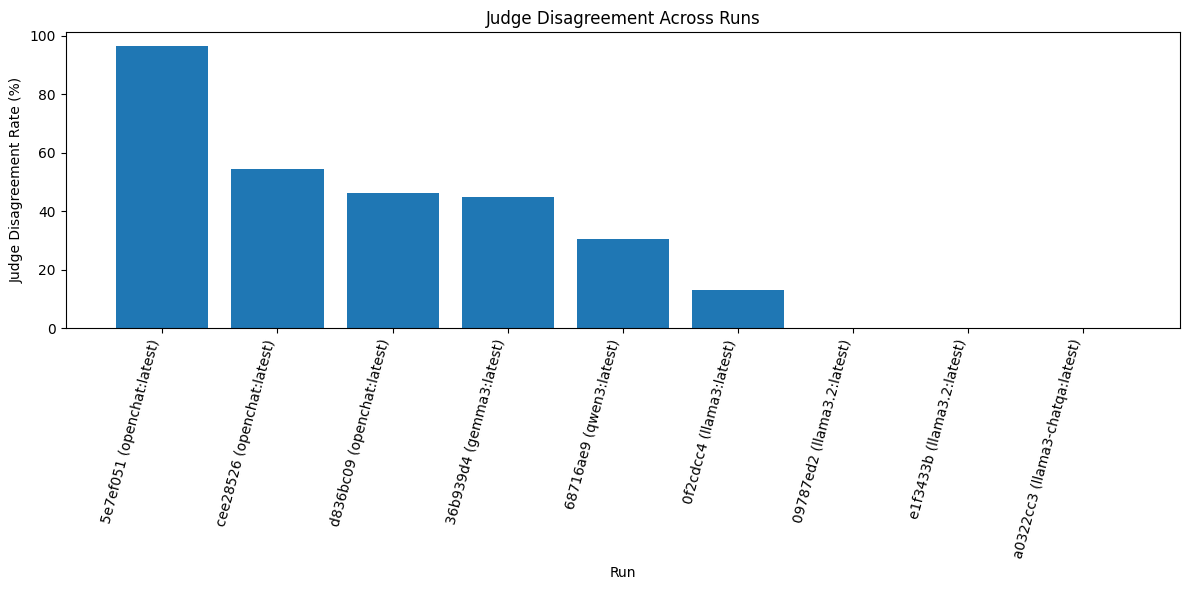

Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\graph_judge_disagreement_by_run.png


In [35]:
g3 = plot_df.dropna(subset=["judge_disagreement_rate_pct"]).sort_values("judge_disagreement_rate_pct", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(g3["run_label"], g3["judge_disagreement_rate_pct"])
plt.ylabel("Judge Disagreement Rate (%)")
plt.xlabel("Run")
plt.title("Judge Disagreement Across Runs")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_judge_disagreement_by_run.png", dpi=220)
plt.show()
print("Saved:", OUT_DIR / "graph_judge_disagreement_by_run.png")


,run_id,target_model,severity,pass_rate_pct,total
0,36b939d4,gemma3:latest,high,61.5,26
1,09787ed2,llama3.2:latest,high,90.9,11
2,cee28526,openchat:latest,medium,63.4,153
3,cee28526,openchat:latest,high,83.0,47
4,d836bc09,openchat:latest,high,61.5,26


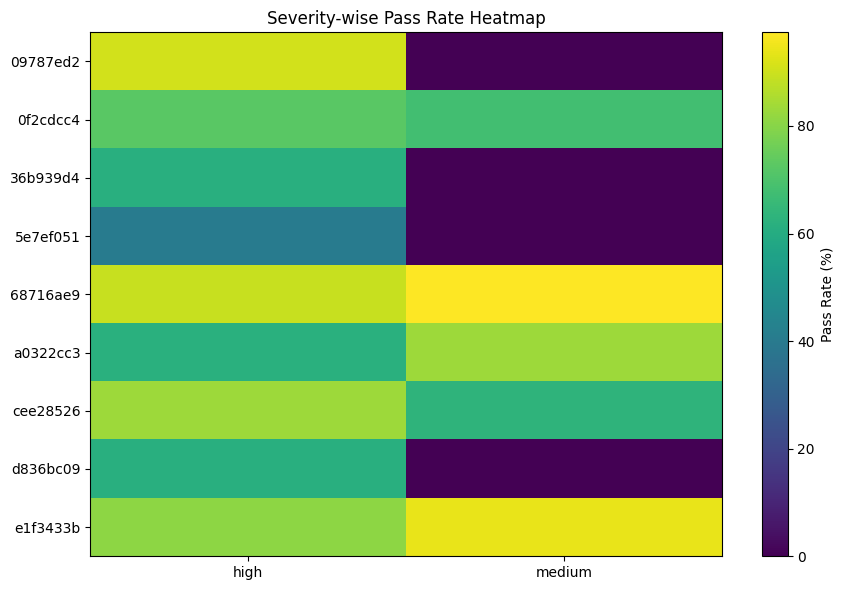

Saved: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\graph_severity_passrate_heatmap.png


In [36]:
sev_rows = []
for _, r in details_df.iterrows():
    sev_stats = r.get("sev_stats") or {}
    if isinstance(sev_stats, dict):
        for sev, sv in sev_stats.items():
            sev_rows.append({
                "run_id": r["run_id"],
                "target_model": r["target_model"],
                "severity": sev,
                "pass_rate_pct": sv.get("pass_rate_pct", np.nan),
                "total": sv.get("total", np.nan),
            })

sev_df = pd.DataFrame(sev_rows)
display(sev_df.head())

if not sev_df.empty:
    pivot = sev_df.pivot_table(index="run_id", columns="severity", values="pass_rate_pct", aggfunc="mean")
    plt.figure(figsize=(9,6))
    plt.imshow(pivot.fillna(0), aspect="auto")
    plt.colorbar(label="Pass Rate (%)")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title("Severity-wise Pass Rate Heatmap")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "graph_severity_passrate_heatmap.png", dpi=220)
    plt.show()
    print("Saved:", OUT_DIR / "graph_severity_passrate_heatmap.png")


## 5. Auto-Generated Observations

In [37]:
judged = details_df[details_df["status"] == "judged"].copy()
judged["pass_rate_pct"] = pd.to_numeric(judged["pass_rate_pct"], errors="coerce")

if not judged.empty:
    best = judged.sort_values("pass_rate_pct", ascending=False).iloc[0]
    worst = judged.sort_values("pass_rate_pct", ascending=True).iloc[0]

    print("Best judged run:", best["run_id"], "| model:", best["target_model"], "| pass rate:", round(best["pass_rate_pct"],2))
    print("Lowest judged run:", worst["run_id"], "| model:", worst["target_model"], "| pass rate:", round(worst["pass_rate_pct"],2))

if "attack_success_rate_pct" in judged.columns:
    tmp = judged[["run_id","attack_success_rate_pct"]].dropna()
    if not tmp.empty:
        high_attack = tmp.sort_values("attack_success_rate_pct", ascending=False).iloc[0]
        print("Highest attack success:", high_attack["run_id"], "|", round(float(high_attack["attack_success_rate_pct"]),2), "%")

notes = []
if not judged.empty:
    notes.append(f"Across {len(judged)} judged runs, pass rate ranges from {judged['pass_rate_pct'].min():.1f}% to {judged['pass_rate_pct'].max():.1f}%.")
    notes.append("Run-level disagreement and critical-failure metrics indicate where single-judge scoring may be unstable.")
    notes.append("Use the model-level table to justify model selection for production hardening.")

obs_path = OUT_DIR / "auto_observations.txt"
obs_path.write_text("".join(notes), encoding="utf-8")
print("Saved observation notes:", obs_path)
print("".join(notes))


Best judged run: 68716ae9 | model: qwen3:latest | pass rate: 95.5
Lowest judged run: 5e7ef051 | model: openchat:latest | pass rate: 40.7
Highest attack success: 5e7ef051 | 59.3 %
Saved observation notes: d:\BDS\BTP\promptmap\graphs\generated\run_analysis_outputs\auto_observations.txt
Across 9 judged runs, pass rate ranges from 40.7% to 95.5%.Run-level disagreement and critical-failure metrics indicate where single-judge scoring may be unstable.Use the model-level table to justify model selection for production hardening.
